# 1. Imports and other

Ruta raíz del proyecto

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\3_prediccion_precios_casas


Añadir ruta raíz al sys, para que se puedan ocupar los archivos de src

In [2]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.visualizations import bar_plot_project, hist_plot_project, scatter_plot_project, reg_plot_project, box_plot_project
import seaborn as sns
from src.utils import simple_report

Definir colores estandar para las visualizaciones

In [4]:
PROJECT_COLORS = ["#2DD61D", "#3410FF"]

Definir ruta para guardar las visualizaciones

In [5]:
FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'figures'
print(FIGURES_PATH)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\3_prediccion_precios_casas\outputs\figures


Leer csv

In [6]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'train.csv')

Filas totales del DataFrame

In [7]:
TOTAL_ROWS = len(df)
TOTAL_ROWS

1460

# 2. General info

In [8]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# 3. Raw EDA

Primero veamos los precios a modo general

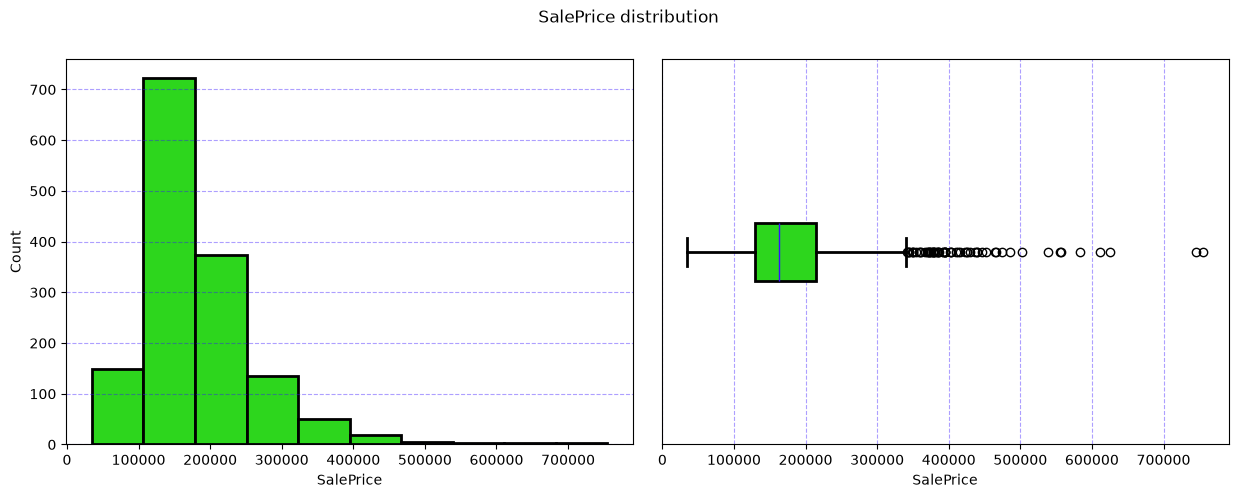

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(
    df['SalePrice'],
    color=PROJECT_COLORS[0],
    edgecolor='black',
    linewidth=2
)
ax[0].set_xlabel('SalePrice')
ax[0].set_ylabel('Count')
ax[0].grid(axis='y', color=PROJECT_COLORS[1], alpha=0.4, linestyle='--')


ax[1].boxplot(
    df['SalePrice'],
    orientation='horizontal',
    patch_artist=True,

    boxprops={
        'facecolor': PROJECT_COLORS[0],
        'edgecolor': 'black',
        'linewidth': 2
    },

    medianprops={
        'color': PROJECT_COLORS[1]
    },

    whiskerprops={
        'color': 'black',
        'linewidth': 2
    },

    capprops={
        'color': 'black',
        'linewidth': 2
    }
)
ax[1].set_xlabel('SalePrice')
ax[1].set_yticks([])
ax[1].grid(axis='x', color=PROJECT_COLORS[1], alpha=0.4, linestyle='--')

fig.suptitle('SalePrice distribution')

fig.subplots_adjust(wspace=0.05)


plt.savefig(FIGURES_PATH / '01_saleprice_general_destribution.png', bbox_inches='tight')
plt.show()

# 3.1 Nulls

Crear DataFrame para identificar features con nulos

In [12]:
df_nulls = pd.DataFrame()

for col in df.columns:
    num_nulls = df[col].isna().sum()
    num_nulls_pct = np.round((num_nulls / TOTAL_ROWS) * 100, 2)

    if num_nulls != 0:
        df_nulls_to_add = pd.DataFrame({
            'Column': [col],
            'Nulls': [num_nulls],
            'Nullspct': [num_nulls_pct]
        })

        df_nulls = pd.concat([df_nulls, df_nulls_to_add])

df_nulls = df_nulls.sort_values(by='Nullspct', ascending=False).reset_index(drop=True)
df_nulls

,Column,Nulls,Nullspct
0,PoolQC,1453,99.52
1,MiscFeature,1406,96.30
2,Alley,1369,93.77
3,Fence,1179,80.75
4,MasVnrType,872,59.73
5,FireplaceQu,690,47.26
6,LotFrontage,259,17.74
7,GarageType,81,5.55
8,GarageYrBlt,81,5.55
9,GarageFinish,81,5.55


In [13]:
df['MasVnrType'].unique()

<StringArray>
['BrkFace', nan, 'Stone', 'BrkCmn']
Length: 4, dtype: str

Features que sus nulos significan auscencia:

- PoolQC
- MiscFeature
- Alley
- Fence
- MasVnrType/MasVnrArea
- FirePlaceQu
- GarageType/GarageYrBlt/GarageFinish/GarageQual/GarageCond
- BsmtExposure/BsmtFinType2/BsmtQual/BsmtCond/BsmtFinType1

Features que sus nulos son falta de información:

- LotFrontage
- Electrical

Ver que contienen los MasVnrArea que tienen NaN

In [14]:
df.loc[
    (df['MasVnrArea'].isna()),
    ['MasVnrType', 'MasVnrArea']
]

,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


Ahora empezaremos a ver los features considerados más importantes a modo general

# 4. Select features (0 -> 14)

Seleccionar de los primeros 15 features, los más interesantes. Las que se encuentran son:

- MSSubClass: Tipo de vivienda
- MSZoning: Tipo de zonificación
- LotArea: Metros cuadrados de propiedad
- LotShape: Forma general de la propiedad
- Utilities: Servicios disponibles
- Neighborhood: Barrio de ubicación de la propiedad

In [15]:
df.iloc[:7, :15]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm


# 5. MSSubClass

## 5.1 Simple report

In [16]:
simple_report(df, 'MSSubClass', show_categories=True)


Nulls: 0
Dtype: int64
Total categories: 15
Categories: [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]



## 5.2 SalePrice mean by MSSubClass

Visualizar promedios de precio

In [17]:
group_mssubclass_mean_sales = df.groupby('MSSubClass')['SalePrice'].agg(['mean', 'count'])
group_mssubclass_mean_sales

,mean,count
MSSubClass,,
20,185224.811567,536
30,95829.724638,69
40,156125.000000,4
45,108591.666667,12
50,143302.972222,144
60,239948.501672,299
70,166772.416667,60
75,192437.500000,16
80,169736.551724,58


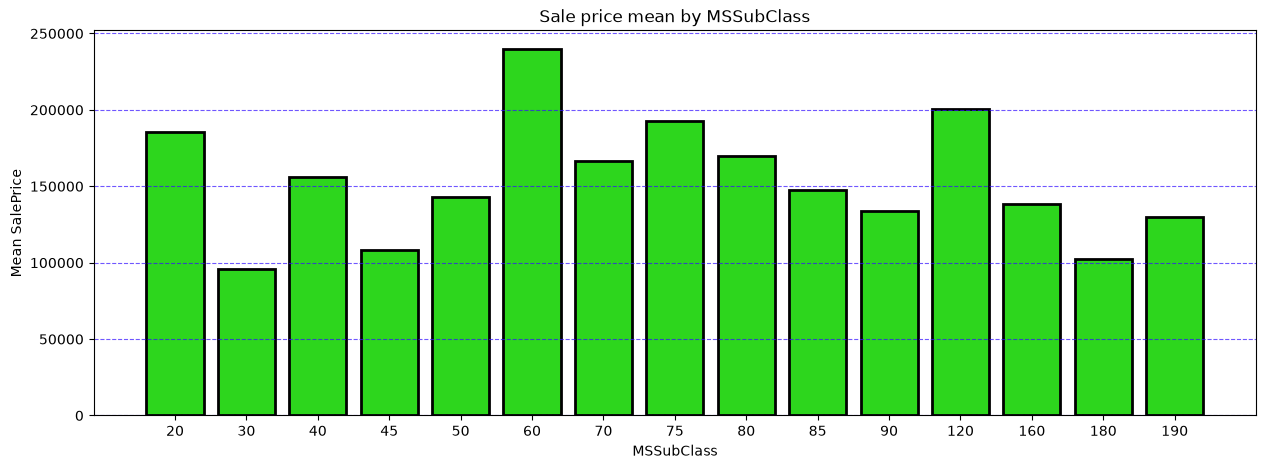

In [18]:
fig, ax = bar_plot_project(
    x=group_mssubclass_mean_sales.index.astype(str),
    height=group_mssubclass_mean_sales['mean'],
    title='Sale price mean by MSSubClass',
    x_label='MSSubClass',
    y_label='Mean SalePrice'
)

plt.savefig(FIGURES_PATH / '02_saleprice_mean_by_mssubclass.png', bbox_inches='tight')
plt.show()

# 6. MSZoning

## 6.1 Simple report

In [19]:
simple_report(df, 'MSZoning', show_categories=True)


Nulls: 0
Dtype: str
Total categories: 5
Categories: ['RL', 'RM', 'C (all)', 'FV', 'RH']



## 6.2 SalePrice distribution by MSZoning

Veamos efecto en SalePrice

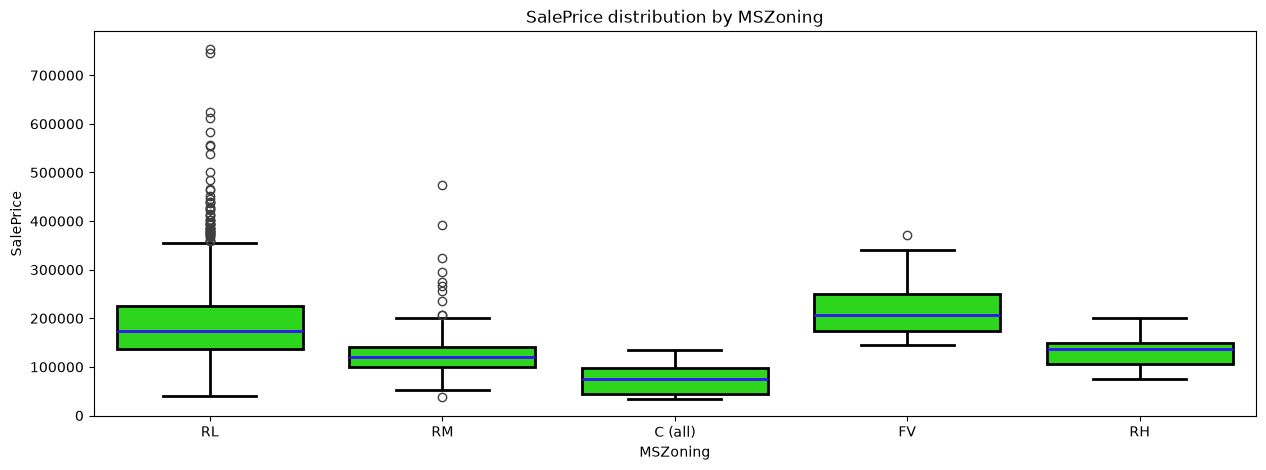

In [20]:
fig, ax = box_plot_project(
    df=df,
    x_name='MSZoning',
    y_name='SalePrice',
    title='SalePrice distribution by MSZoning'
)

plt.savefig(FIGURES_PATH / '03_saleprice_distbox_by_mszoning.png', bbox_inches='tight')
plt.show()

# 7. LotArea

## 7.1 Simple report

In [21]:
simple_report(df, 'LotArea')


Nulls: 0
Dtype: int64
Total categories: 1073



## 7.2 Distribution

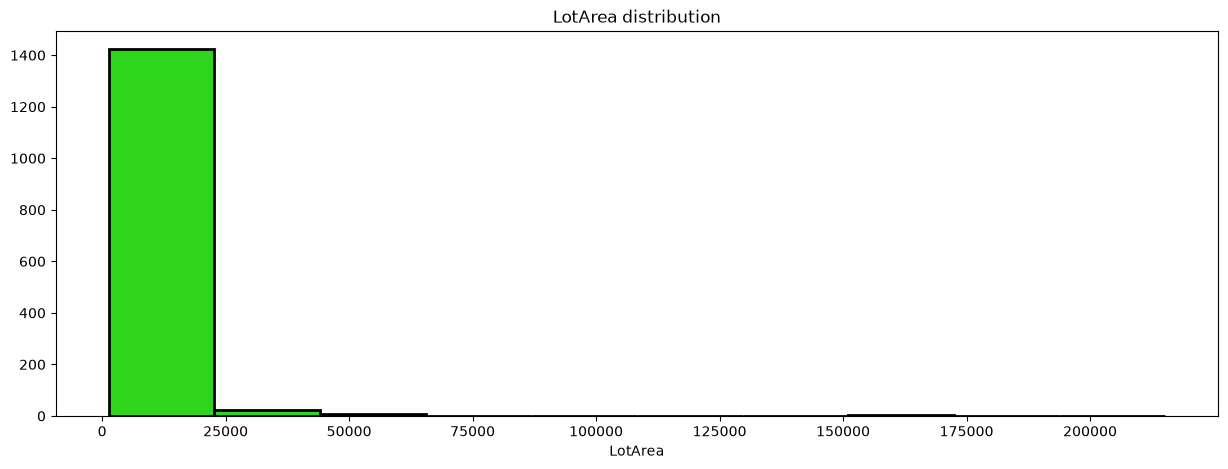

In [22]:
fig, ax = hist_plot_project(
    x=df['LotArea'],
    title='LotArea distribution',
    x_label='LotArea'
)

ax.set_xticks(range(0, 200001, 25000))


plt.savefig(FIGURES_PATH / '04_lotarea_dist.png', bbox_inches='tight')
plt.show()

## 7.3 Distribution with SalePrice

SalePrice by LotArea

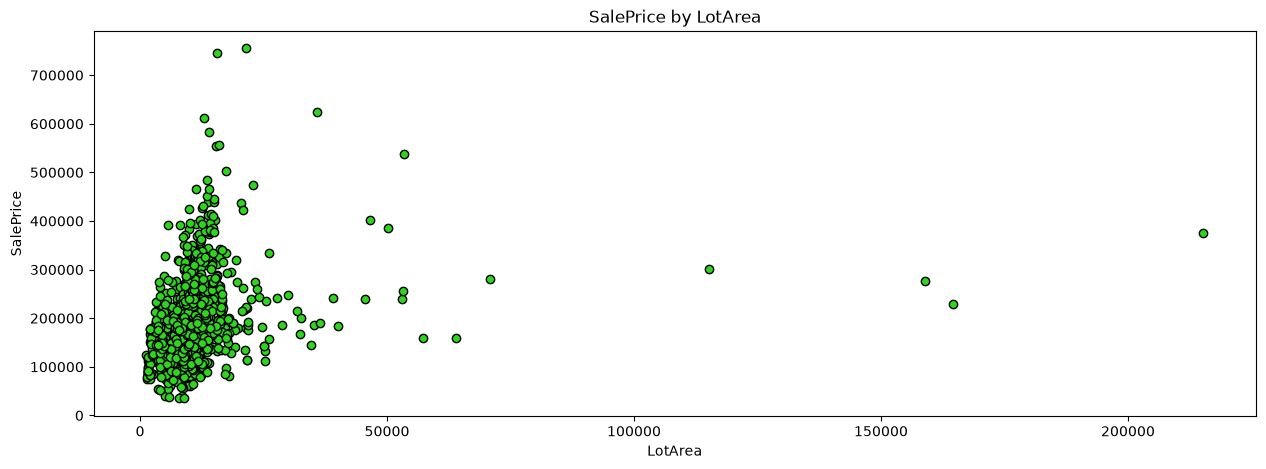

In [23]:
fig, ax = scatter_plot_project(
    x=df['LotArea'],
    y=df['SalePrice'],
    title='SalePrice by LotArea',
    x_label='LotArea',
    y_label='SalePrice'
)


plt.savefig(FIGURES_PATH / '04_01_saleprice_by_lotarea.png', bbox_inches='tight')
plt.show()

Regplot SalePrice by LotArea

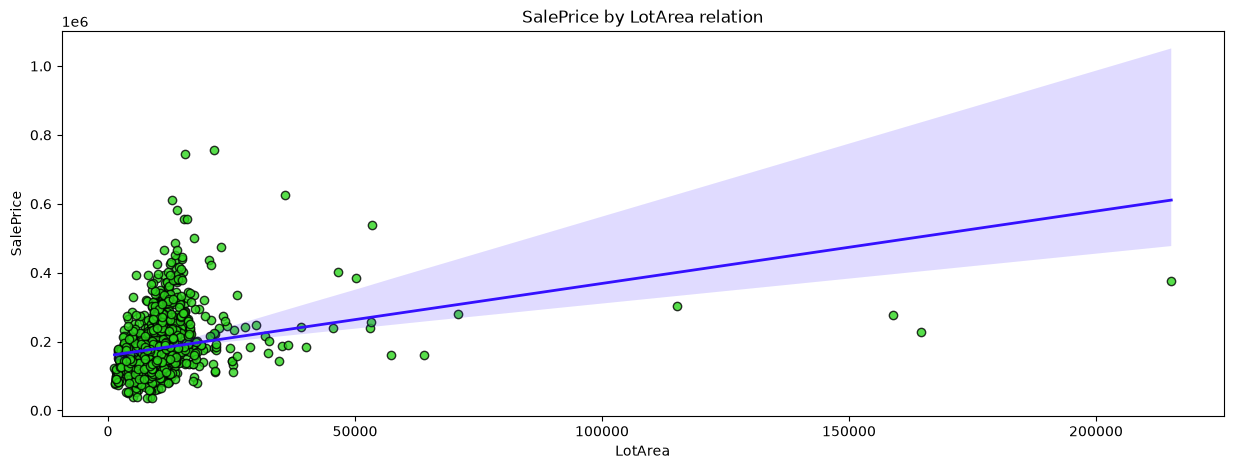

In [24]:
fig, ax = reg_plot_project(
    df=df,
    x_name='LotArea',
    y_name='SalePrice',
    title='SalePrice by LotArea relation'
)

plt.savefig(FIGURES_PATH / '04_02_saleprice_by_lotarea_regplot.png', bbox_inches='tight')
plt.show()

Hay unos cuantos outliers que no nos permiten ver claramente la relación, así que la investigaremos de forma que no los consideremos.

SalePrice by LotArea < 25000

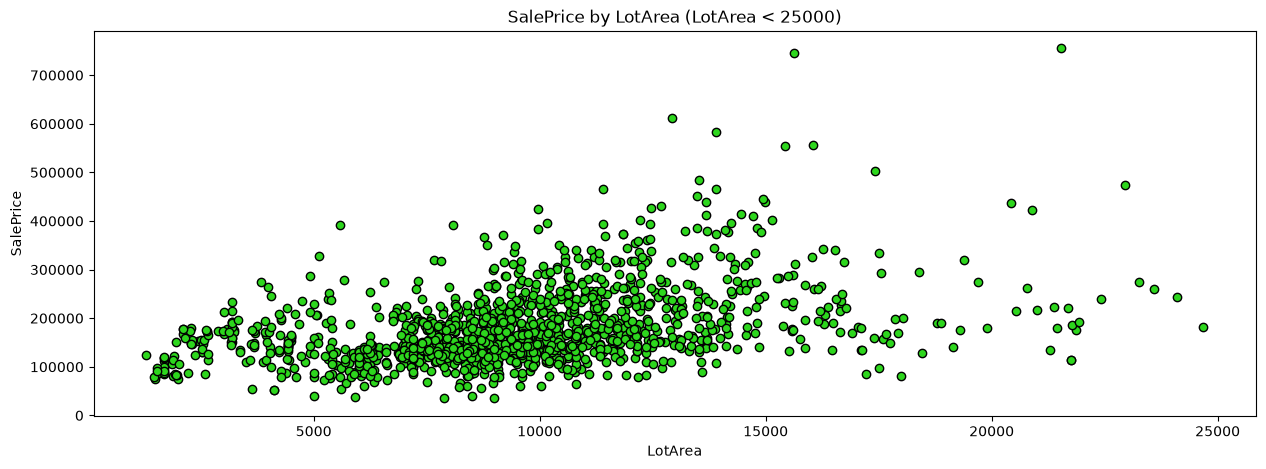

In [25]:
fig, ax = scatter_plot_project(
    x=df.loc[
        df['LotArea'] < 25000,
        ['LotArea']
    ],
    y=df.loc[
        df['LotArea'] < 25000,
        ['SalePrice']
    ],
    title='SalePrice by LotArea (LotArea < 25000)',
    x_label='LotArea',
    y_label='SalePrice'
)


plt.savefig(FIGURES_PATH / '04_03_saleprice_by_lotarea_below25000.png', bbox_inches='tight')
plt.show()

Regplot SalePrice by LotArea < 25000

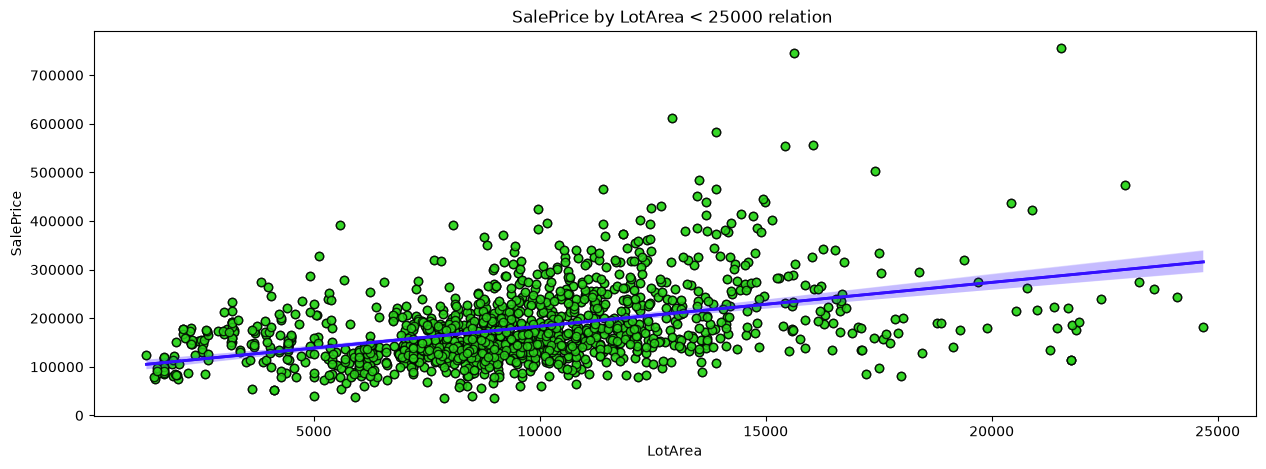

In [26]:
fig, ax = reg_plot_project(
    df=df[df['LotArea'] < 25000],
    x_name='LotArea',
    y_name='SalePrice',
    title='SalePrice by LotArea < 25000 relation '
)

sns.regplot(
    data=df[df['LotArea'] < 25000],
    x='LotArea',
    y='SalePrice',
    ax=ax,
    scatter_kws={
        'color': PROJECT_COLORS[0],
        'edgecolor': 'black'
    },
    line_kws={
        'color': PROJECT_COLORS[1],
        'linewidth': 2
    }
)

plt.savefig(FIGURES_PATH / '04_04_saleprice_by_lotarea_below25000_regplot.png', bbox_inches='tight')
plt.show()

# 8. LotShape

## 8.1 Simple report

In [27]:
simple_report(df, 'LotShape', show_categories=True)


Nulls: 0
Dtype: str
Total categories: 4
Categories: ['Reg', 'IR1', 'IR2', 'IR3']



## 8.2 SalePrice distribution by LotShape

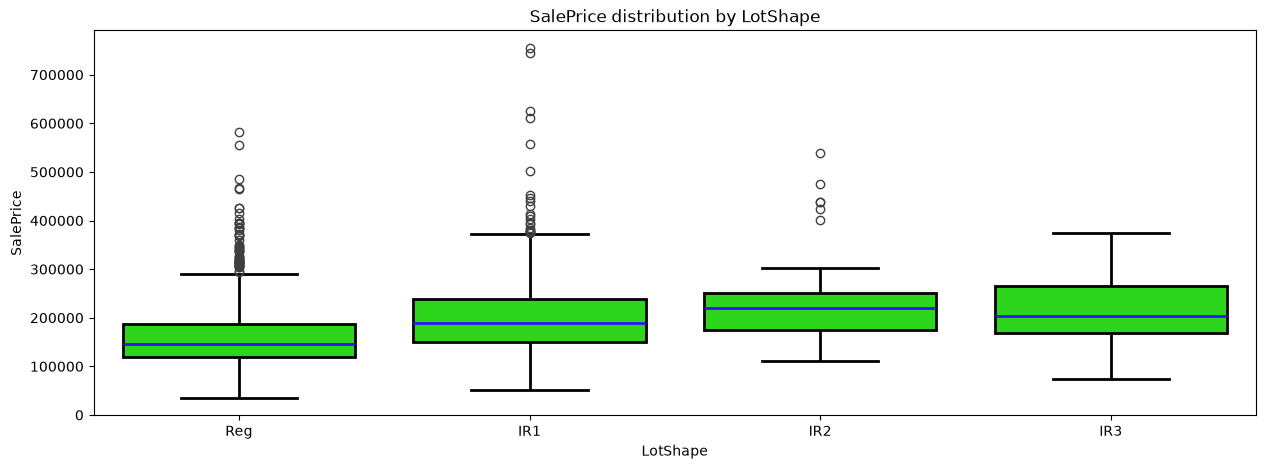

In [28]:
fig, ax = box_plot_project(
    df=df,
    x_name='LotShape',
    y_name='SalePrice',
    title='SalePrice distribution by LotShape'
)

plt.savefig(FIGURES_PATH / '05_saleprice_distbox_by_lotshape.png', bbox_inches='tight')
plt.show()

# 9. Utilities

## 9.1 Simple report

In [29]:
simple_report(df, 'Utilities', show_categories=True)


Nulls: 0
Dtype: str
Total categories: 2
Categories: ['AllPub', 'NoSeWa']



## 9.2 Value count

In [30]:
value_counts_utilities = df['Utilities'].value_counts()
value_counts_utilities

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Casi todos las categorías son AllPub, asi que esta feature la ignoraremos por el momento

# 10. Neighborhood

## 10.1 Simple report

In [31]:
simple_report(df, 'Neighborhood', show_categories=True)


Nulls: 0
Dtype: str
Total categories: 25
Categories: ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst', 'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes', 'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU', 'Blueste']



## 10.2 SalePrice mean by Neighborhood

In [32]:
group_neighborhood_mean_sales = df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
group_neighborhood_mean_sales

,mean,count
Neighborhood,,
NoRidge,335295.317073,41
NridgHt,316270.623377,77
StoneBr,310499.000000,25
Timber,242247.447368,38
Veenker,238772.727273,11
Somerst,225379.837209,86
ClearCr,212565.428571,28
Crawfor,210624.725490,51
CollgCr,197965.773333,150


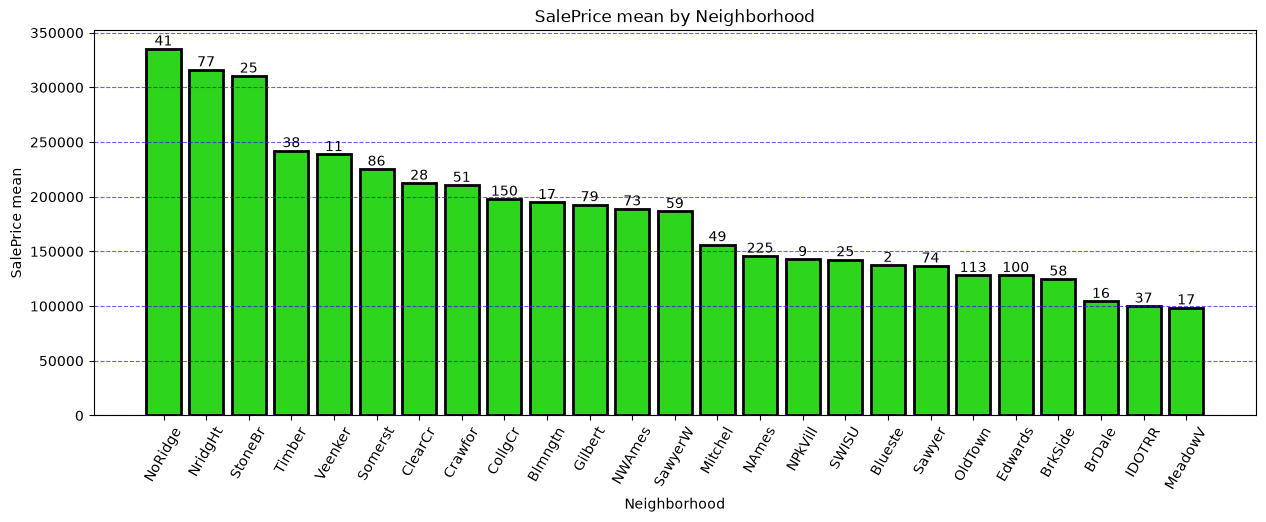

In [33]:
fig, ax = bar_plot_project(
    x=group_neighborhood_mean_sales.index,
    height=group_neighborhood_mean_sales['mean'],
    title='SalePrice mean by Neighborhood',
    x_label='Neighborhood',
    y_label='SalePrice mean'
)

ax.tick_params(axis='x', rotation=60)

for bars in ax.containers:
    ax.bar_label(bars, labels=group_neighborhood_mean_sales['count'])

plt.savefig(FIGURES_PATH / '06_saleprice_mean_by_neighborhood.png', bbox_inches='tight')
plt.show()

# 11. Select features (15 -> 29)

Veamos features interesantes

In [34]:
df.iloc[:7, 15:30]

,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation
0,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc
1,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock
2,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc
3,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil
4,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc
5,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood
6,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc


Seleccionaremos las siguientes:

- OverallQual: Calidad del material y terminaciónes de la propiedad en general
- OverallCond: Condición general de la casa
- YearBuilt: Año de construcción
- ExterQual: Calidad de material del exterior
- ExterCond: Condición del material del exterior

# 12. OverallQual

## 12.1 Simple report

In [35]:
simple_report(df, 'OverallQual', show_categories=True)


Nulls: 0
Dtype: int64
Total categories: 10
Categories: [ 7  6  8  5  9  4 10  3  1  2]



## 12.2 SalePrice by OverallQual

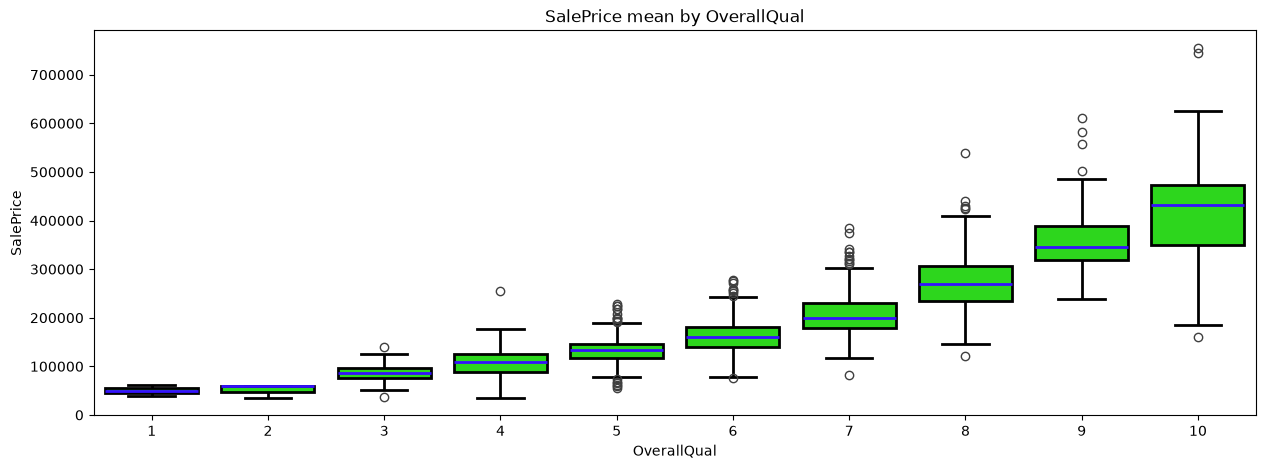

In [36]:
fig, ax = box_plot_project(
    df,
    x_name='OverallQual',
    y_name='SalePrice',
    title='SalePrice mean by OverallQual'
)


plt.savefig(FIGURES_PATH / '07_saleprice_mean_by_overallqual.png', bbox_inches='tight')
plt.show()

# 13. OverallCond

## 13.1 Simple report

In [37]:
simple_report(df, 'OverallCond', show_categories=True)


Nulls: 0
Dtype: int64
Total categories: 9
Categories: [5 8 6 7 4 2 3 9 1]



## 13.2 SalePrice by OverallCond

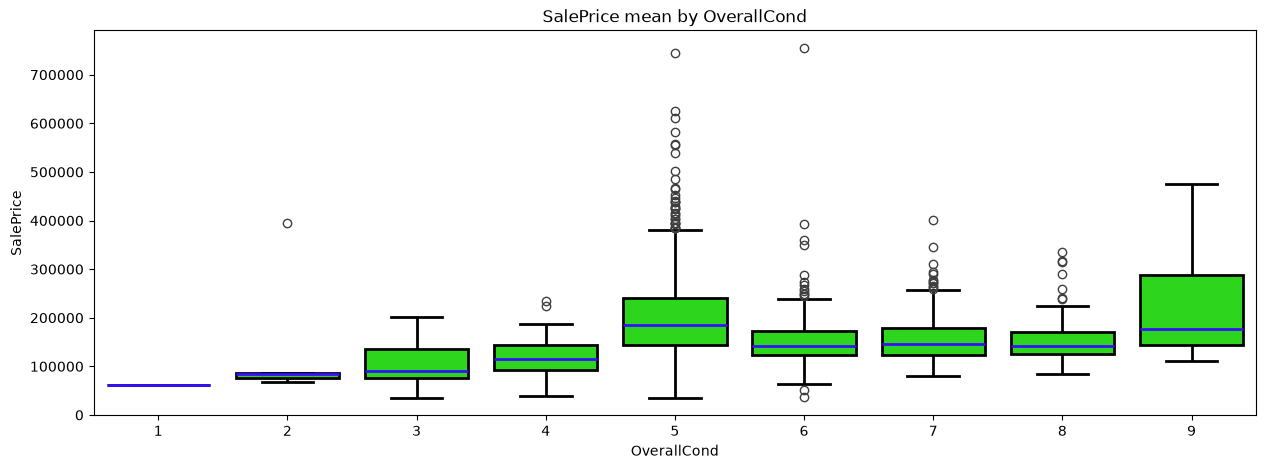

In [38]:
fig, ax = box_plot_project(
    df,
    x_name='OverallCond',
    y_name='SalePrice',
    title='SalePrice mean by OverallCond'
)

plt.savefig(FIGURES_PATH / '08_saleprice_mean_by_overallcond.png', bbox_inches='tight')
plt.show()

# 14. YearBuilt

## 14.1 Simple report

In [39]:
simple_report(df, 'YearBuilt')


Nulls: 0
Dtype: int64
Total categories: 112



## 14.2 SalePrice by YearBuilt

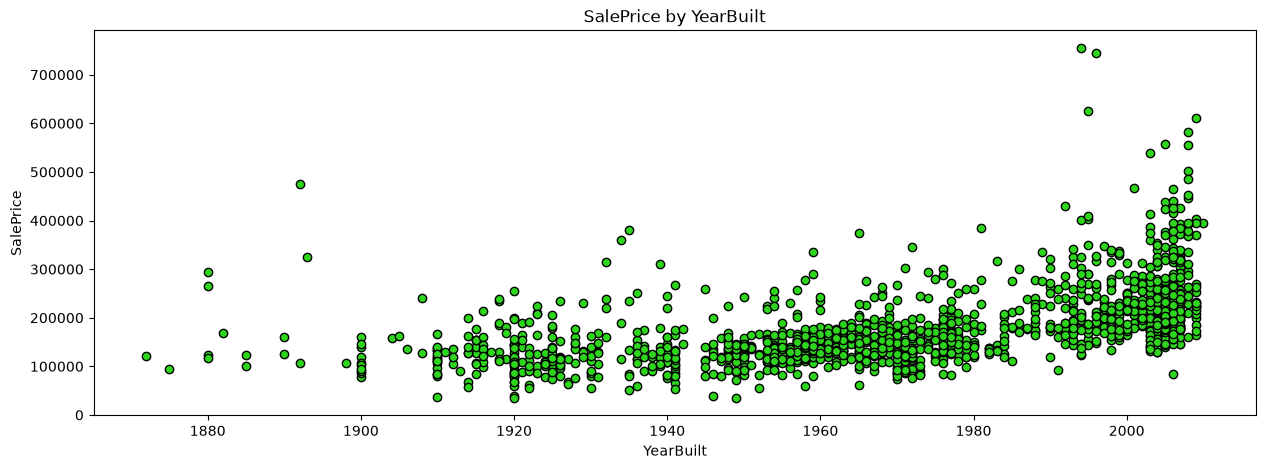

In [40]:
fig, ax = scatter_plot_project(
    x=df['YearBuilt'],
    y=df['SalePrice'],
    title='SalePrice by YearBuilt',
    x_label='YearBuilt',
    y_label='SalePrice'
)

plt.savefig(FIGURES_PATH / '09_saleprice_by_yearbuilt.png', bbox_inches='tight')
plt.show()

Regplot SalePrice by YearBuilt

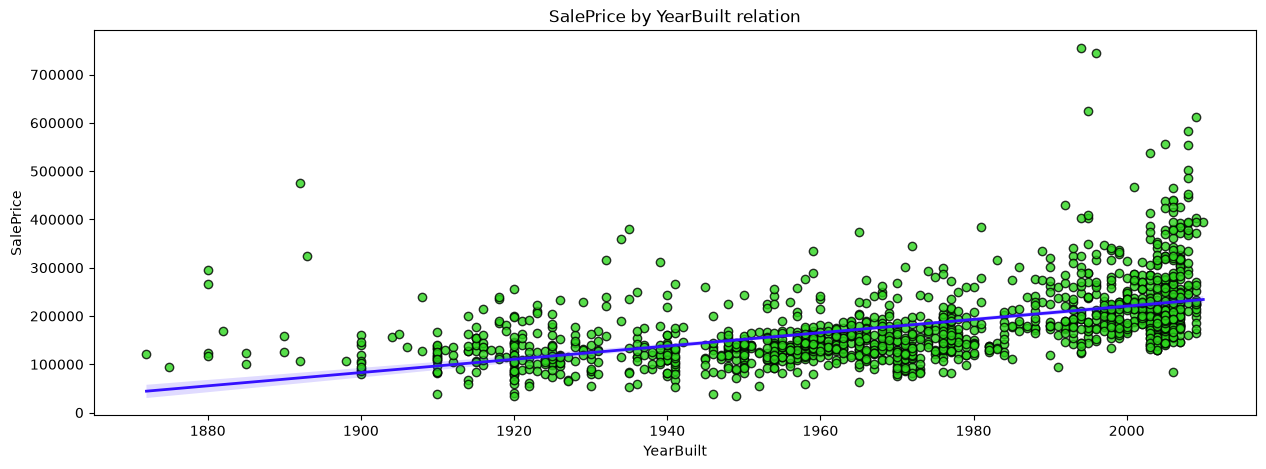

In [41]:
fig, ax = reg_plot_project(
    df=df,
    x_name='YearBuilt',
    y_name='SalePrice',
    title='SalePrice by YearBuilt relation'
)

plt.savefig(FIGURES_PATH / '09_01_saleprice_by_yearbuilt_regplot.png', bbox_inches='tight')
plt.show()

# 15. ExterQual

## 15.1 Simple report

In [42]:
simple_report(df, 'ExterQual', show_categories=True)


Nulls: 0
Dtype: str
Total categories: 4
Categories: ['Gd', 'TA', 'Ex', 'Fa']



## 15.2 SalePrice by ExterQual

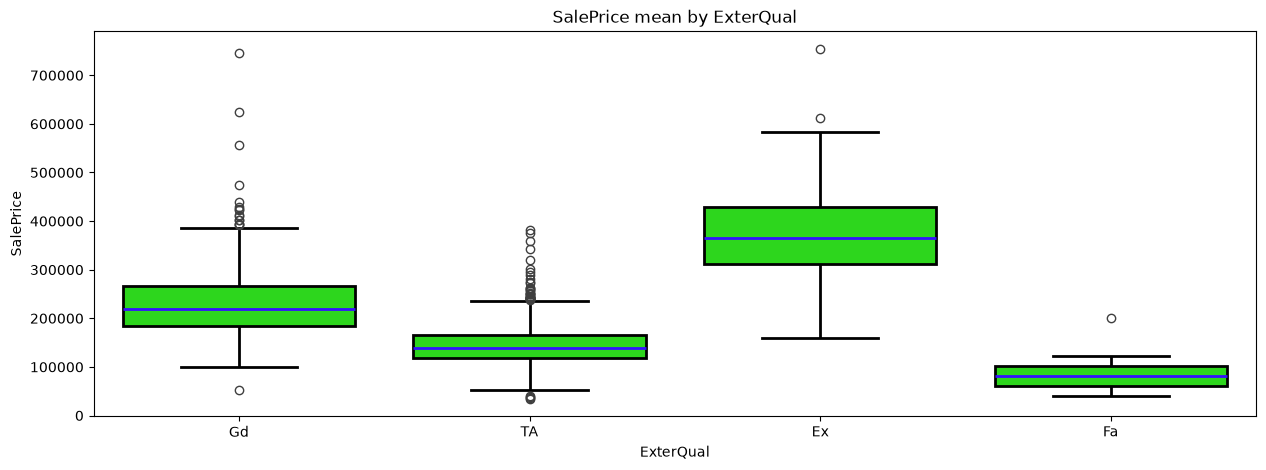

In [43]:
fig, ax = box_plot_project(
    df,
    x_name='ExterQual',
    y_name='SalePrice',
    title='SalePrice mean by ExterQual'
)


plt.savefig(FIGURES_PATH / '10_saleprice_mean_by_exterqual.png', bbox_inches='tight')
plt.show()

# 16. ExterCond

## 16.1 Simple report

In [44]:
simple_report(df, 'ExterCond', show_categories=True)


Nulls: 0
Dtype: str
Total categories: 5
Categories: ['TA', 'Gd', 'Fa', 'Po', 'Ex']



## 16.2 SalePrice by ExterCond

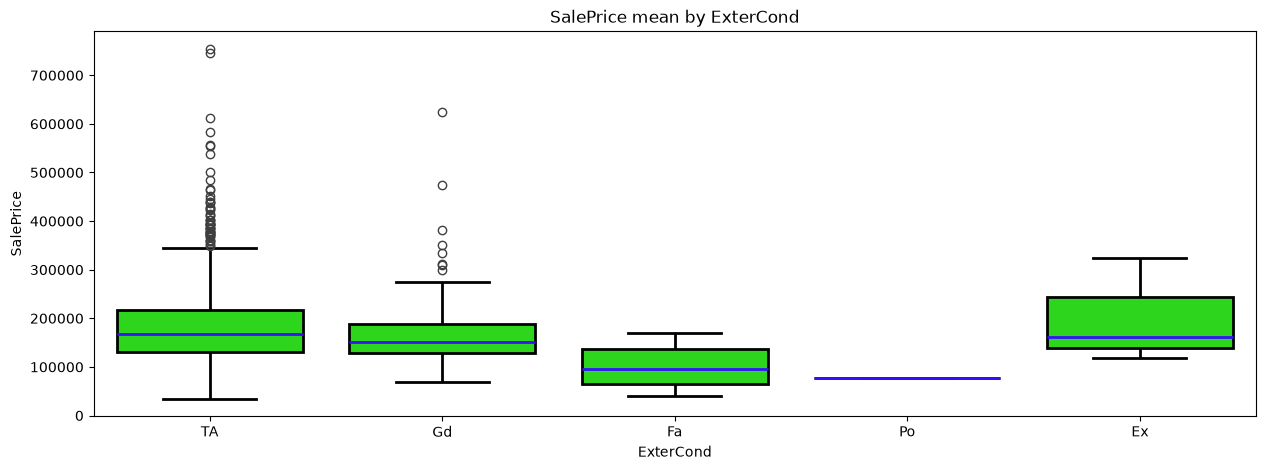

In [45]:
fig, ax = box_plot_project(
    df,
    x_name='ExterCond',
    y_name='SalePrice',
    title='SalePrice mean by ExterCond'
)


plt.savefig(FIGURES_PATH / '11_saleprice_mean_by_extercond.png', bbox_inches='tight')
plt.show()

# 17. Select features (30 -> 44)

Features interesantes

In [46]:
df.iloc[:7, 30:45]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF
0,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854
1,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0
2,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866
3,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756
4,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053
5,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566
6,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0


- BsmtQual: Calidad del sótano
- BsmtCond: Condición del sótano
- HeatingQC: Calidad de la calefacción
- 1stFlrSF: Pies cuadrados del primer piso
- 2stFlrSF: Pies cuadrados del segundo piso

# 18. BsmtQual

## 18.1 Simple report

In [47]:
simple_report(df, 'BsmtQual', show_categories=True)


Nulls: 37
Dtype: str
Total categories: 4
Categories: ['Gd', 'TA', 'Ex', nan, 'Fa']



## 18.2 SalePrice by BsmtQual

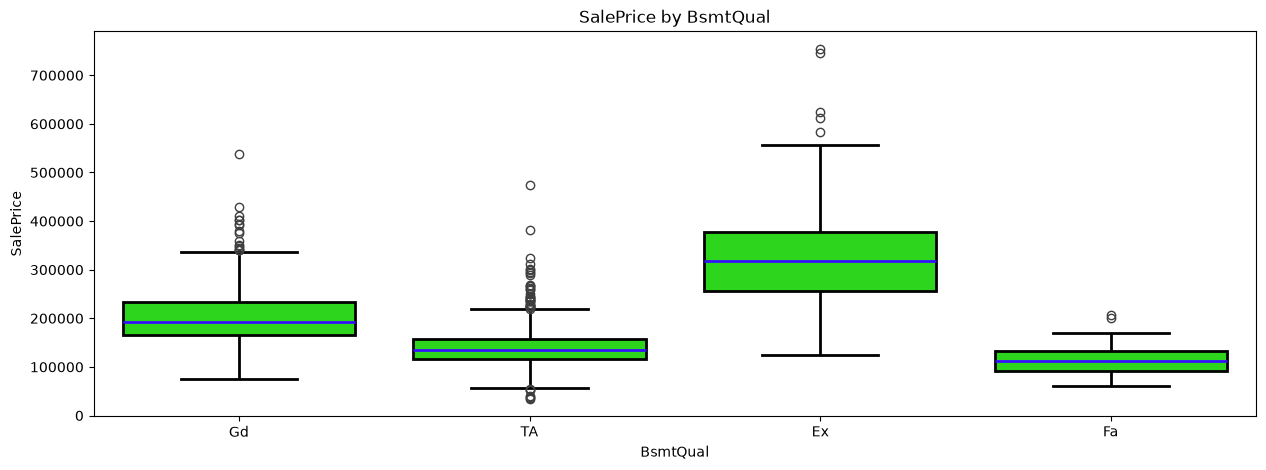

In [49]:
fig, ax = box_plot_project(
    df=df,
    x_name='BsmtQual',
    y_name='SalePrice',
    title='SalePrice by BsmtQual'
)

plt.savefig(FIGURES_PATH / '12_saleprice_by_bsmtqual.png', bbox_inches='tight')
plt.show()